In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("DelayedFlights_Sample.csv")

## Tworzenie modelu 


In [22]:
X = df.drop(columns=["ArrDelay15","DepDelay15","FlightDate"])
y = df["ArrDelay15"]

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [25]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [26]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1907 3492]
 [1507 7368]]


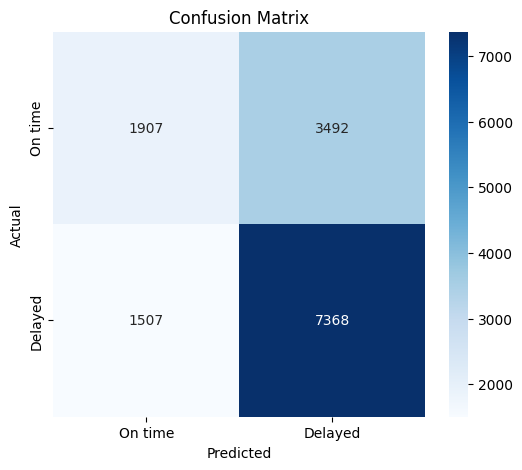

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["On time","Delayed"],
            yticklabels=["On time","Delayed"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC AUC:", auc)

Accuracy: 0.6497828219139694
ROC AUC: 0.6678231597400667


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.35      0.43      5399
           1       0.68      0.83      0.75      8875

    accuracy                           0.65     14274
   macro avg       0.62      0.59      0.59     14274
weighted avg       0.63      0.65      0.63     14274



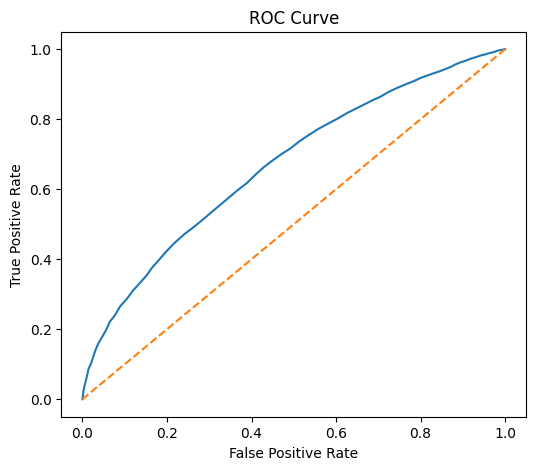

In [30]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


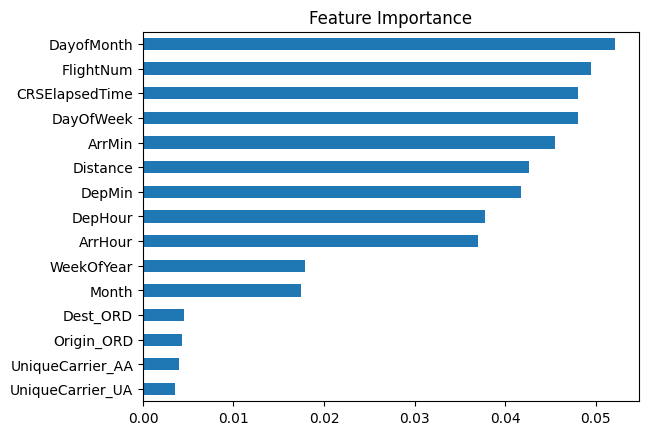

In [31]:
importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values().tail(15).plot(kind="barh")
plt.title("Feature Importance")
plt.show()